# RUL Calculation and Leakage-Safe Feature Engineering

## Objective

This notebook prepares the NASA C-MAPSS FD001 training data for predictive modeling.

The main objectives are:

1. Calculate Remaining Useful Life (`RUL`) for every engine cycle.
2. Distinguish between the prediction target and model features.
3. Create historical sensor features using only information available up to the current cycle.
4. Prevent data leakage from future engine observations.
5. Validate the engineered features before moving to model development.

The features created in this notebook are demonstrated using sensor `s2`. The same leakage-safe methods can later be applied to other selected sensors inside the modeling pipeline.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_cmapss_data
from src.rul_builder import add_train_rul
from src.preprocessing import add_sensor_history_features
from src.config import EMA_SPAN, ROLLING_WINDOW, RUL_CAP

## Load the FD001 Training Data

The FD001 training dataset contains complete run-to-failure histories
for multiple engines.

Each row represents one engine at one operating cycle and includes:

- Engine ID
- Current operating cycle
- Three operational settings
- Twenty-one sensor measurements

The dataset is loaded through the reusable `load_cmapss_data`
function from `src/data_loader.py`, ensuring that the same loading
logic is shared across the project.

In [2]:
data_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

df = load_cmapss_data(data_path)

df.head()

,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print("Dataset shape:", df.shape)
print("Number of engines:", df["id"].nunique())
print("Missing values:", df.isna().sum().sum())

df.dtypes

Dataset shape: (20631, 26)
Number of engines: 100
Missing values: 0


id             int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
s1           float64
s2           float64
s3           float64
s4           float64
s5           float64
s6           float64
s7           float64
s8           float64
s9           float64
s10          float64
s11          float64
s12          float64
s13          float64
s14          float64
s15          float64
s16          float64
s17            int64
s18            int64
s19          float64
s20          float64
s21          float64
dtype: object

## Sort the Data by Engine and Cycle

Time-dependent features such as differences, rolling averages, exponential moving averages, and expanding statistics require the observations to be in the correct chronological order.

Therefore, the dataset is sorted first by engine ID and then by operating cycle.

In [4]:
df = (
    df.sort_values(["id", "cycle"])
      .reset_index(drop=True)
)

df[["id", "cycle"]].head(10)

,id,cycle
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
5,1,6
6,1,7
7,1,8
8,1,9
9,1,10


# Remaining Useful Life Target

Remaining Useful Life (`RUL`) represents the number of operating cycles
remaining before an engine reaches the end of its recorded lifetime.

For engine $i$ at cycle $t$, the original linear target is:

$$
RUL_{linear,i,t} = T_i - t
$$

where:

- $T_i$ is the final observed cycle of engine $i$,
- $t$ is the current operating cycle.

A controlled target-ablation study in Notebook 06 showed that the model
performed substantially better in the operationally relevant
degradation region when a capped target was used.

The final project target is therefore:

$$
RUL_{capped,i,t}
=
\min\left(
RUL_{linear,i,t},
RUL_{max}
\right)
$$

with:

$$
RUL_{max} = 125
$$

The cap represents an early healthy operating region in which the
sensor measurements may not contain enough information to distinguish
precisely between very large RUL values.

The value of 125 is treated as an empirically evaluated modeling
configuration rather than a universal physical constant.

The target is created using `add_train_rul` from
`src/rul_builder.py`, with the cap provided through `src/config.py`.

In [5]:
df = add_train_rul(
    df,
    rul_cap=RUL_CAP,
)

df[["id", "cycle", "RUL"]].head(10)

,id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [6]:
rul_validation = (
    df.groupby("id")
      .agg(
          first_cycle=("cycle", "min"),
          final_cycle=("cycle", "max"),
          maximum_rul=("RUL", "max"),
          final_rul=("RUL", "min")
      )
)

rul_validation.head()

,first_cycle,final_cycle,maximum_rul,final_rul
id,,,,
1,1,192,125,0
2,1,287,125,0
3,1,179,125,0
4,1,189,125,0
5,1,269,125,0


In [7]:
assert "RUL" in df.columns

assert "max_cycle" not in df.columns, (
    "Future engine lifetime information must not remain in the DataFrame."
)

assert df["RUL"].min() == 0, (
    "RUL must reach zero at the final cycle."
)

assert df["RUL"].max() == RUL_CAP, (
    "The capped RUL target must reach the configured maximum."
)

assert (df["RUL"] <= RUL_CAP).all(), (
    "RUL values must not exceed the configured cap."
)

assert (df["RUL"] >= 0).all(), (
    "RUL must not contain negative values."
)

assert (df.groupby("id").tail(1)["RUL"] == 0).all(), (
    "The final cycle of every engine must have RUL equal to zero."
)

print("Capped RUL validation passed.")

Capped RUL validation passed.


In [8]:
linear_rul = (
    df.groupby("id")["cycle"]
    .transform("max")
    - df["cycle"]
)

capped_rows = (
    linear_rul > RUL_CAP
).sum()

capped_percentage = (
    capped_rows
    / len(df)
    * 100
)

print("Rows affected by RUL capping:", capped_rows)
print(
    f"Percentage affected by capping: "
    f"{capped_percentage:.2f}%"
)

Rows affected by RUL capping: 8031
Percentage affected by capping: 38.93%


### Target Engineering Insight

Approximately 39% of the FD001 training observations belong to the
early healthy region where linear RUL exceeds 125 cycles.

Under the final capped target, these observations share the same target
value.

This prevents the model from being forced to distinguish precise
high-RUL values when the sensor signals may still reflect broadly
similar healthy operating behavior.

The controlled target-ablation study in Notebook 06 showed that the
capped target substantially improved prediction accuracy within the
shared critical region where the linear and capped RUL definitions are
identical.

## Target Construction and Data Leakage

The final recorded cycle of each training engine is required to
construct its historical RUL label.

This information is available only because the training dataset contains
complete run-to-failure histories.

However, the final lifetime of an operating engine would not be known
in real time.

Therefore:

- the final observed cycle is used only inside the target-construction
  function,
- it is not retained as a DataFrame column,
- it is never included in the model feature set,
- and the capped target does not introduce future information into the
  input features.

The cap changes the supervised-learning objective, but it does not
expose the model to the future lifetime of an engine.

# Leakage-Safe Historical Feature Engineering

In a real operational environment, the prediction system has access only to:

- The current sensor measurements
- Measurements recorded during previous cycles
- The current operating cycle

It does not have access to future sensor values.

For this reason, every historical feature below is calculated separately for each engine and uses only data available up to the current cycle.

The historical features are generated through the reusable
`add_sensor_history_features` function from `src/preprocessing.py`.

The function supports multiple sensors, configurable rolling windows,
and configurable EMA spans. In this notebook, `s2` is used as a
demonstration sensor before applying the same process to the final
sensor set selected during sensor analysis.

The rolling window and EMA span are both configured as 10 cycles.

This configuration was selected through the controlled temporal-window
ablation in Notebook 06, which compared values of 3, 5, 10, and 20
cycles while keeping the sensor set, target, model hyperparameters, and
engine-level validation split fixed.

The 10-cycle configuration achieved the strongest validation MAE, RMSE,
and R² and is therefore used throughout the finalized modeling pipeline.

In [9]:
feature_sensors = ["s2"]

df = add_sensor_history_features(
    df,
    sensors=feature_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

In [10]:
feature_columns = [
    "id",
    "cycle",
    "s2",
    "s2_diff_1",
    f"s2_rolling_mean_{ROLLING_WINDOW}",
    f"s2_ema_{EMA_SPAN}",
    "s2_expanding_mean",
]

df[feature_columns].head(10)

,id,cycle,s2,s2_diff_1,s2_rolling_mean_10,s2_ema_10,s2_expanding_mean
0,1,1,641.82,0.00,641.820000,641.820000,641.820000
1,1,2,642.15,0.33,641.985000,641.880000,641.985000
2,1,3,642.35,0.20,642.106667,641.965455,642.106667
3,1,4,642.35,0.00,642.167500,642.035372,642.167500
4,1,5,642.37,0.02,642.208000,642.096213,642.208000
5,1,6,642.10,-0.27,642.190000,642.096902,642.190000
6,1,7,642.48,0.38,642.231429,642.166556,642.231429
7,1,8,642.56,0.08,642.272500,642.238091,642.272500
8,1,9,642.12,-0.44,642.255556,642.216620,642.255556
9,1,10,641.71,-0.41,642.201000,642.124507,642.201000


## 1. Raw Sensor Value

The original `s2` measurement is preserved.

Raw sensor values are important because they retain immediate changes, sudden spikes, and short-term variations that may be hidden by smoothing methods.

## 2. One-Cycle Sensor Difference

The one-cycle difference measures how much the sensor value has changed
relative to the previous cycle of the same engine.

For sensor value $(x_t)$:

$$
\Delta x_t = x_t - x_{t-1}
$$

For the first cycle of each engine, no previous observation exists, so
the difference is initialized to zero.

This feature uses only the current and previous observations and
therefore does not introduce future-data leakage.

## 3. Rolling Mean

A rolling mean reduces short-term fluctuations and provides a view of
the recent local sensor trend.

For a rolling window of size $w$:

$$
\bar{x}^{(w)}_t =
\frac{1}{m_t}
\sum_{k=\max(1,t-w+1)}^{t} x_k
$$

where $m_t$ is the number of available observations inside the window
at cycle $t$.

The final project configuration uses:

$$
w = 10
$$

At each cycle, the feature therefore uses the current observation and
up to nine previous observations from the same engine.

The raw sensor value remains available alongside the rolling feature so
that sudden changes are not completely hidden.

The 10-cycle value was selected empirically in Notebook 06 rather than
being treated as an arbitrary default.

## 4. Exponential Moving Average

The Exponential Moving Average (`EMA`) represents the recent sensor
trend while assigning greater weight to newer observations.

It is defined recursively as:

$$
EMA_t = \alpha x_t + (1-\alpha)EMA_{t-1}
$$

For a span value $(s)$, pandas uses:

$$
\alpha = \frac{2}{s+1}
$$

The finalized project configuration uses:

$$
s = 10
$$

Compared with a simple rolling mean, EMA reacts more quickly to recent
changes because newer observations receive greater weight.

The calculation is performed independently for each engine and uses
only the current and previous cycles.

The 10-cycle span was selected through the controlled temporal-window
ablation in Notebook 06.

## 5. Expanding Mean

The expanding mean provides a cumulative historical baseline for each
engine.

At cycle $(t)$:

$$
\bar{x}^{exp}_t =
\frac{1}{t}
\sum_{k=1}^{t} x_k
$$

It uses all observations recorded from the first cycle up to and
including the current cycle.

Unlike a full-engine average, the expanding mean does not use future
observations. Its baseline therefore grows dynamically as new cycles
become available.

## Same-Cycle Prediction Assumption

The historical features in this notebook include the current cycle
measurement $(x_t)$.

The operational assumption is:

> RUL is predicted after the sensor readings for the current cycle have
> been received.

Under this assumption, using $(x_t)$ is valid and does not constitute
data leakage.

If the deployment objective were instead to predict cycle $(t)$ before
its measurements became available, every sensor-derived feature would
need to be shifted by one cycle:

$$
x^{lagged}_t = x_{t-1}
$$

A same-cycle versus one-cycle-lagged ablation may be evaluated later as
a deployment-oriented robustness experiment.

In [11]:
engine_1_features = df.loc[
    df["id"] == 1,
    [
        "id",
        "cycle",
        "s2",
        "s2_diff_1",
        f"s2_rolling_mean_{ROLLING_WINDOW}",
        f"s2_ema_{EMA_SPAN}",
        "s2_expanding_mean",
        "RUL",
    ],
]

engine_1_features.head(15)

,id,cycle,s2,s2_diff_1,s2_rolling_mean_10,s2_ema_10,s2_expanding_mean,RUL
0,1,1,641.82,0.00,641.820000,641.820000,641.820000,125
1,1,2,642.15,0.33,641.985000,641.880000,641.985000,125
2,1,3,642.35,0.20,642.106667,641.965455,642.106667,125
3,1,4,642.35,0.00,642.167500,642.035372,642.167500,125
4,1,5,642.37,0.02,642.208000,642.096213,642.208000,125
5,1,6,642.10,-0.27,642.190000,642.096902,642.190000,125
6,1,7,642.48,0.38,642.231429,642.166556,642.231429,125
7,1,8,642.56,0.08,642.272500,642.238091,642.272500,125
8,1,9,642.12,-0.44,642.255556,642.216620,642.255556,125
9,1,10,641.71,-0.41,642.201000,642.124507,642.201000,125


## Feature Validation

The following checks confirm that:

1. The first-cycle difference is zero for every engine.
2. The historical features contain no missing values.
3. Feature engineering preserves the original number of rows.
4. The future-only `max_cycle` column is absent from the DataFrame.
5. The target column is not part of the demonstration feature list.

In [12]:
engineered_features = [
    f"{sensor}_{suffix}"
    for sensor in feature_sensors
    for suffix in [
        "diff_1",
        f"rolling_mean_{ROLLING_WINDOW}",
        f"ema_{EMA_SPAN}",
        "expanding_mean",
    ]
]

first_cycles = df.groupby("id").head(1)

for sensor in feature_sensors:
    assert (first_cycles[f"{sensor}_diff_1"] == 0).all(), (
        f"The first {sensor} difference must be zero for every engine."
    )

assert df[engineered_features].isna().sum().sum() == 0, (
    "Engineered features must not contain missing values."
)

assert len(df) == 20631, (
    "Feature engineering must not change the number of dataset rows."
)

expected_order = (
    df[["id", "cycle"]]
    .sort_values(["id", "cycle"])
    .reset_index(drop=True)
)

actual_order = (
    df[["id", "cycle"]]
    .reset_index(drop=True)
)

assert actual_order.equals(expected_order), (
    "The dataset must remain sorted by engine id and cycle."
)

assert "max_cycle" not in df.columns, (
    "Future lifetime information must not remain in the DataFrame."
)

assert "RUL" not in engineered_features, (
    "The target column must not be included in engineered features."
)

print("Leakage-safe feature validation passed.")

Leakage-safe feature validation passed.


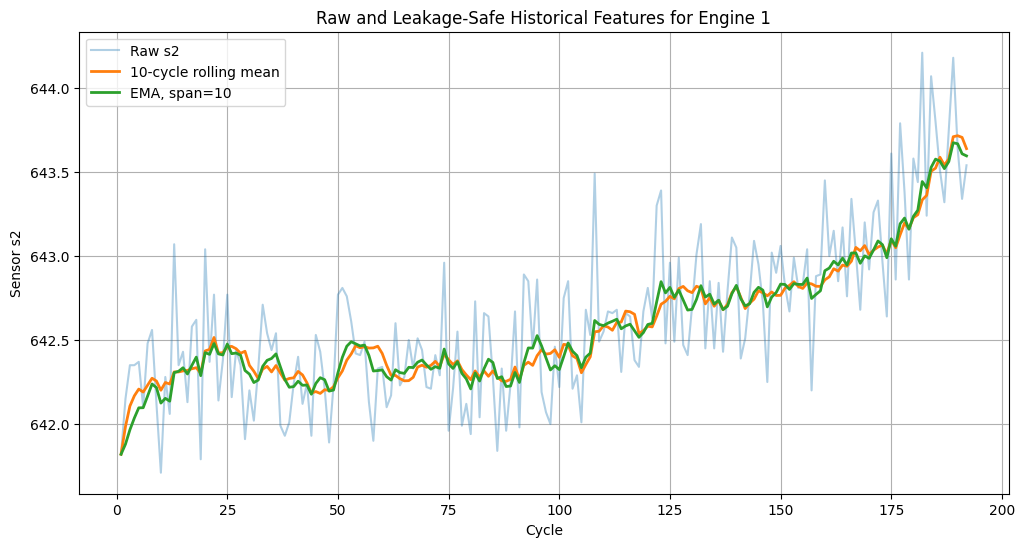

In [13]:
engine_id = 1

engine_df = df[df["id"] == engine_id]

plt.figure(figsize=(12, 6))

plt.plot(
    engine_df["cycle"],
    engine_df["s2"],
    alpha=0.35,
    label="Raw s2"
)

plt.plot(
    engine_df["cycle"],
    engine_df[f"s2_rolling_mean_{ROLLING_WINDOW}"],
    linewidth=2,
    label=f"{ROLLING_WINDOW}-cycle rolling mean"
)

plt.plot(
    engine_df["cycle"],
    engine_df[f"s2_ema_{EMA_SPAN}"],
    linewidth=2,
    label=f"EMA, span={EMA_SPAN}"
)

plt.title("Raw and Leakage-Safe Historical Features for Engine 1")
plt.xlabel("Cycle")
plt.ylabel("Sensor s2")
plt.legend()
plt.grid(True)
plt.show()

### Insight

The raw `s2` signal contains short-term fluctuations and preserves immediate changes in sensor behavior.

The 10-cycle rolling mean produces a smoother local trend but may react
more slowly to sudden changes because all observations inside the
window receive equal weight.

The EMA also smooths the signal but gives greater importance to recent observations, allowing it to respond more quickly to new changes.

For future modeling, the raw signal and selected historical features can be evaluated together. Their actual usefulness must be determined through validation performance rather than assumed from visualization alone.

# Modeling Feature Policy

The following existing columns are excluded from model inputs:

- `id`: an engine identifier, not a degradation measurement
- `RUL`: the supervised-learning target

The following future-derived columns must not be created as model
features:

- `max_cycle`: the unknown final lifetime of the engine
- `cycle_progress` based on the actual final cycle

The current cycle is operationally available and may be evaluated as a
model feature.

For this demonstration, the leakage-safe candidate features are:

- `cycle`
- Raw `s2`
- `s2_diff_1`
- `s2_rolling_mean_<window>`
- `s2_ema_<span>`
- `s2_expanding_mean`

The final modeling pipeline will apply appropriate historical
transformations to the sensors selected during sensor analysis.

In [14]:
target_column = "RUL"

excluded_from_features = [
    "id",
    "RUL"
]

forbidden_future_columns = [
    "max_cycle",
    "cycle_progress"
]

demonstration_features = [
    "cycle",
    "s2",
    "s2_diff_1",
    f"s2_rolling_mean_{ROLLING_WINDOW}",
    f"s2_ema_{EMA_SPAN}",
    "s2_expanding_mean",
]

assert target_column not in demonstration_features

assert not any(
    column in demonstration_features
    for column in forbidden_future_columns
)

print("Target:", target_column)
print("Excluded existing columns:", excluded_from_features)
print("Forbidden future-derived columns:", forbidden_future_columns)
print("Demonstration features:", demonstration_features)

Target: RUL
Excluded existing columns: ['id', 'RUL']
Forbidden future-derived columns: ['max_cycle', 'cycle_progress']
Demonstration features: ['cycle', 's2', 's2_diff_1', 's2_rolling_mean_10', 's2_ema_10', 's2_expanding_mean']


# Final Summary

In this notebook:

1. The FD001 training data was loaded through the shared project data
   loader.
2. A capped RUL target with a maximum value of 125 cycles was created
   using the reusable RUL builder.
3. The future final lifetime of each engine was isolated from the model
   feature set.
4. Raw sensor values were retained alongside one-cycle differences,
   rolling means, exponential moving averages, and expanding means.
5. All historical features were calculated independently for each
   engine using only currently available and past observations.
6. The final rolling window and EMA span were set to 10 cycles based on
   the controlled ablation study in Notebook 06.
7. The mathematical definitions remain documented in the Notebook,
   while their executable implementations remain centralized in the
   source modules.

The prepared feature-engineering policy is now aligned with the final
target and temporal configuration selected for the project.